In [1]:
%load_ext autoreload
%autoreload 2

# Explicabilité et axes d’amélioration

## Objectif
- Argument commercial : RICA, transformation de vieux documents  
- OCR : nécessité sur documents anciens  
- Fonctionnement universel : tout type d’image, tout type de modèle  

## Pourquoi LIME
- Indépendant du modèle (model-agnostic)  
- Explication visuelle locale  
- Identification des zones influentes  
- Adaptable à plusieurs architectures  
- Limite : ne gère pas les grandes images → découpage en patchs  

## Problèmes
- Vitesse : superpixels, bruitage, régression lents  
- Code : redondances, recalculs, paramètres fixes  
- Généralisation : dépendance à YOLO, classes multiples mal gérées  
- Régression : locale seulement, pas d’explication globale  
- Multiplicité des paramètres qui changent le résultat

## Améliorations
- Optimisation : vectorisation, parallélisation  
- Structure : fonctions propres, config centralisée  
- Flexibilité : compatibilité multi-modèles  
- Explicabilité : régression sur image complète  
- GitHub : README détaillé, pipeline et évolutions


# I. En entrée : une image + un model de classification

## I.1. Chargement de l'image 

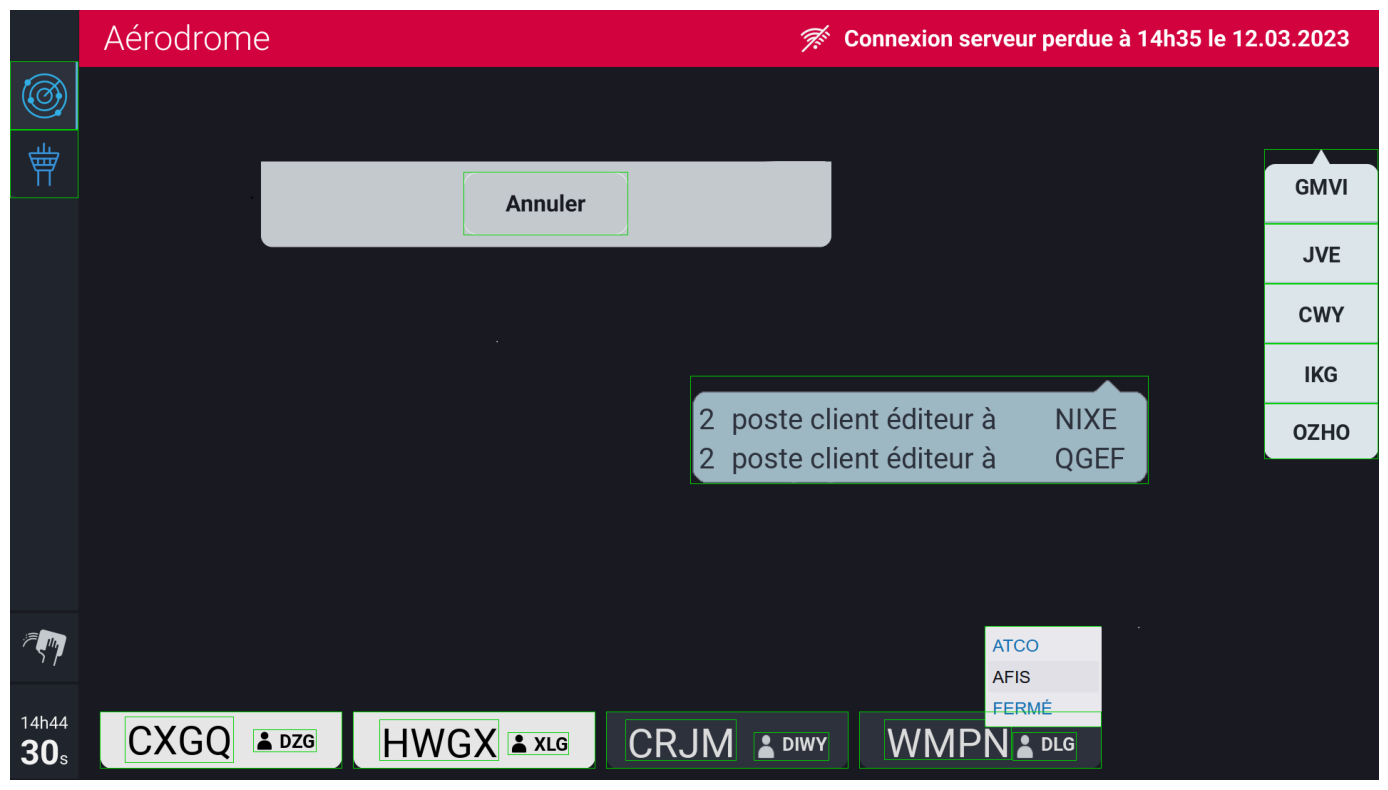

In [2]:
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/home/jmerhrioui/soprasteria/semaine_2/data/dataset_y/images/validation/validation_image_4.png"
image = Image.open(img_path)
plt.figure(figsize=(20,10))
plt.imshow(image)
plt.axis('off')
plt.show()



## I.2. Chargement du model 

YOLOv5 🚀 v7.0-443-gbe00b6b6 Python-3.12.3 torch-2.8.0+cu128 CPU

Fusing layers... 
Model summary: 416 layers, 140509144 parameters, 0 gradients, 209.1 GFLOPs
Adding AutoShape... 
/home/jmerhrioui/soprasteria/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


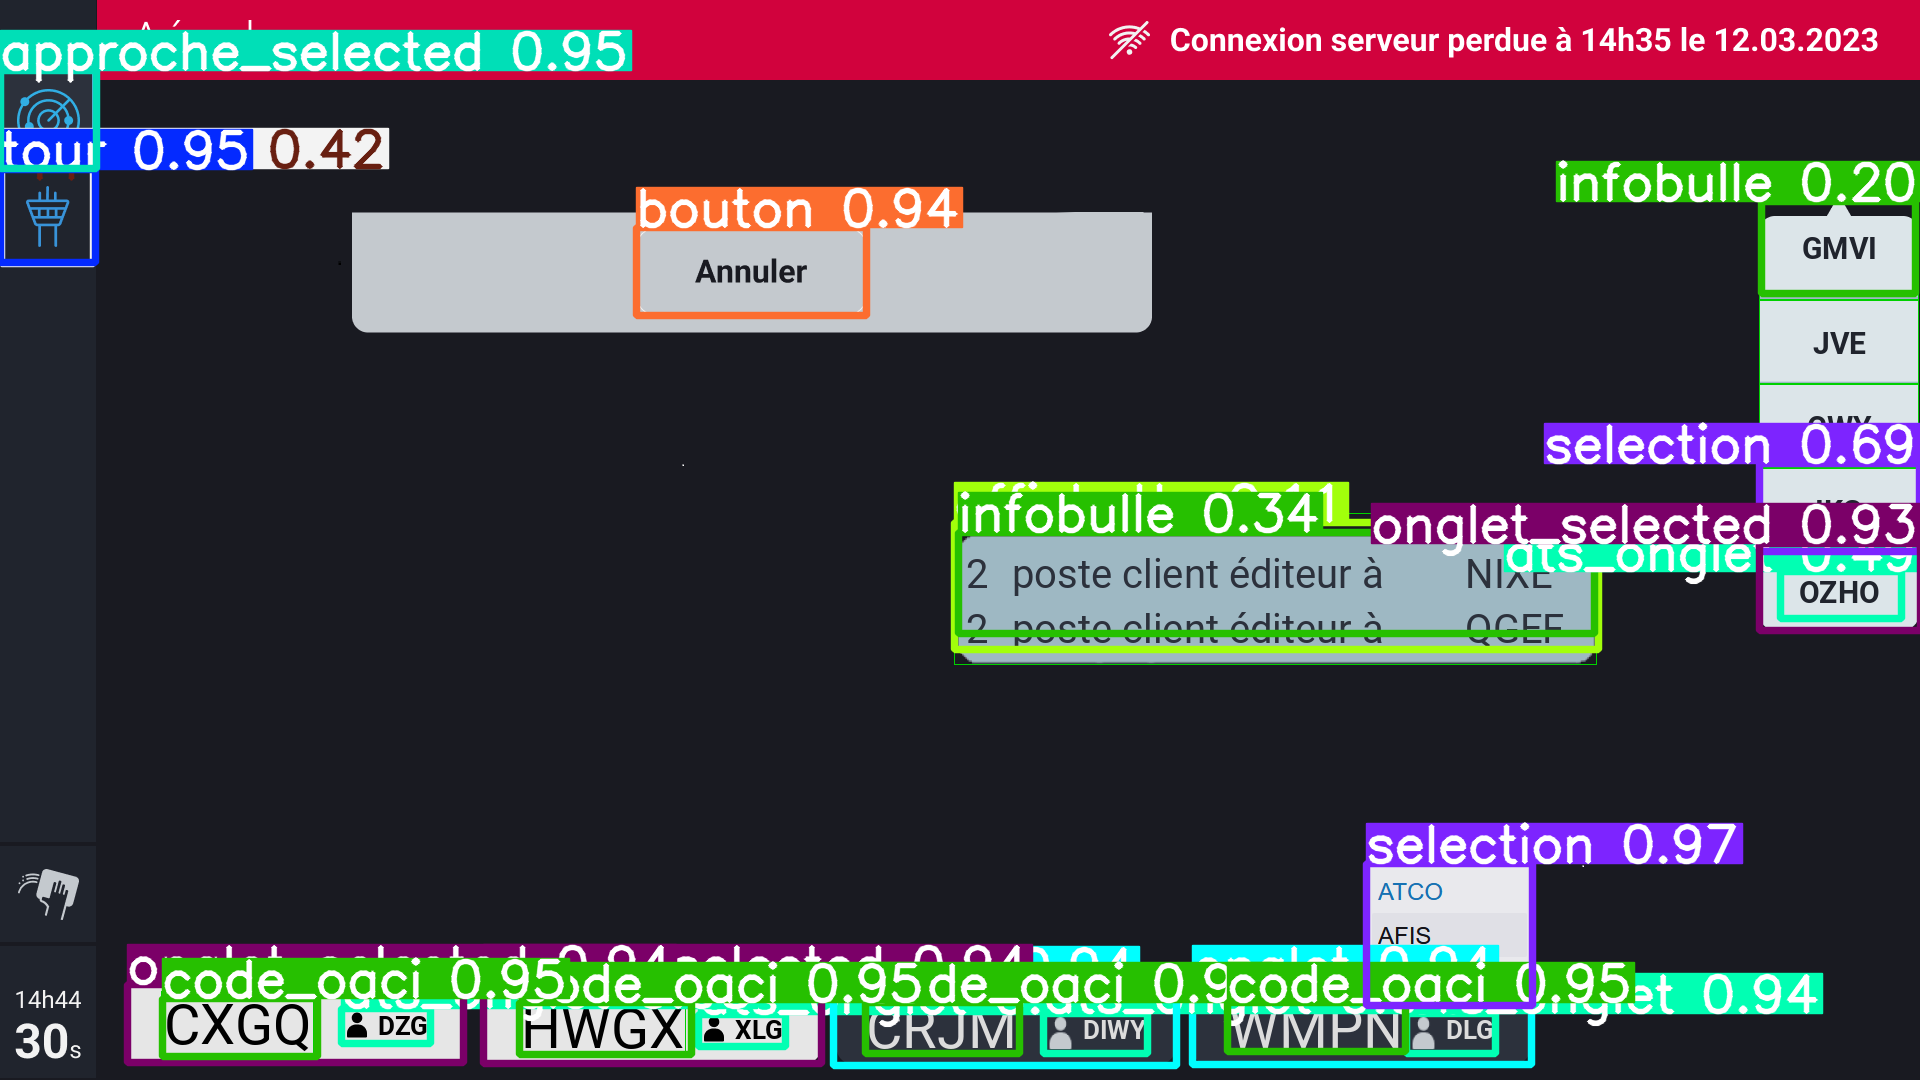

0             selection
1     approche_selected
2             code_oaci
3             code_oaci
4             code_oaci
5             code_oaci
6                  tour
7       onglet_selected
8       onglet_selected
9                bouton
10               onglet
11           ats_onglet
12           ats_onglet
13               onglet
14           ats_onglet
15           ats_onglet
16      onglet_selected
17            selection
18           ats_onglet
19             approche
20            infobulle
21            infobulle
22           affichette
           xmin         ymin         xmax         ymax  confidence  class  \
0   1366.799927   863.898926  1532.084351  1005.672363    0.971856     55   
1      0.432990    70.835884    96.237404   168.781555    0.952497      3   
2    162.854340   998.451233   317.229950  1056.972656    0.952227     53   
3   1227.174683  1002.255798  1405.389038  1051.142212    0.951315     53   
4    519.667236  1002.454468   691.588440  1054.178589    0.950

In [3]:
import torch
from ultralytics import YOLO
from torchinfo import summary
import pandas as pd

model_path = "/home/jmerhrioui/soprasteria/semaine_2/model/best.pt" # model entrainé 
yolo_model = torch.hub.load('/home/jmerhrioui/soprasteria/yolov5', 'custom', path=model_path, source='local')
yolo_model.conf = 0.1 # Confidence threshold
yolo_model.iou = 0.4 # NMS IoU threshold
results = yolo_model(img_path)  
results.show()

summary(yolo_model)

df = results.pandas().xyxy[0]
print(df["name"].to_string())
print(df)

## I.3. Identification de la zone à tester 

### Image de taille 1920 * 1080 --> 48 * 27 ( Patchs de taille 40 par 40 )

In [4]:
import matplotlib.pyplot as plt
import numpy as np 
from PIL import Image 

# PARAMETRES DE BASE 

sp_batch_size = 3
n_segments = 20
compactness = 5
patch_size = 40


In [5]:
from superpixels.sp import superpixels
from lime.regression import regression

# --- INITIALISATION DES OBJETS ---
sp = superpixels(batch_size=sp_batch_size, n_segments=n_segments, compactness=compactness)
# instance qui construit les superpixels
reg = regression(batch_size=sp_batch_size, n_segments=n_segments, compactness=compactness, alpha=1)
# instance de la regression : images bruitées, accuracy

27 48
1296
Figure créée : Figure(2000x1000)


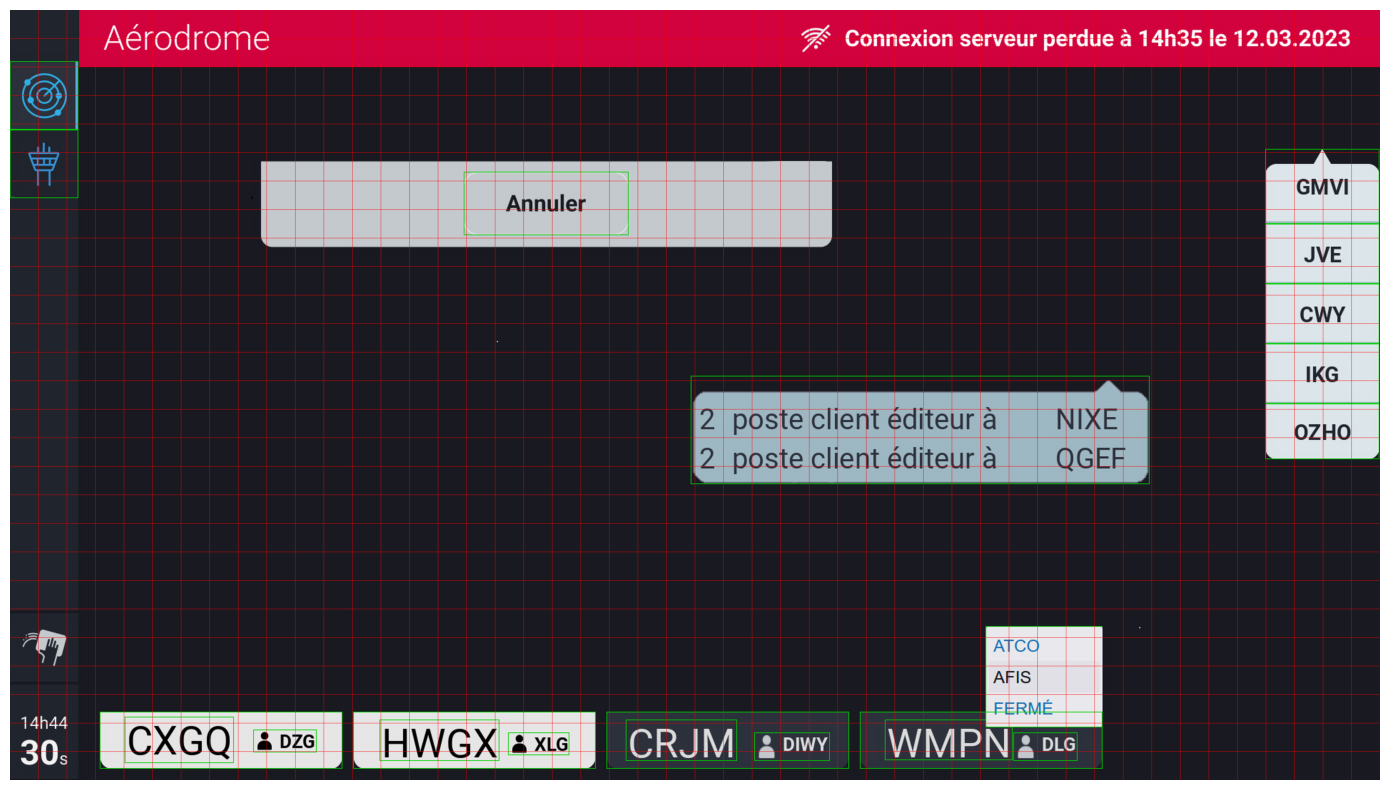

In [6]:
%matplotlib inline
liste, imgs, img_base_striee = sp.load_image(patch_size)
# liste : liste des patchs à bruiter
# imgs : image de base
# img_base_striee : image de base avec les superpixels affichés

fig = plt.figure(figsize=(20,10))
plt.imshow(np.clip(img_base_striee, 0, 1))
plt.axis('off')
print("Figure créée :", fig)
plt.show()

## On identifie les patchs à bruiter 
- Lignes 6 et _8_
- Colonnes 16 à 22

In [7]:
import numpy as np


l_min, l_max = 6, 7
c_min, c_max = 16, 22
diff = (c_max - c_min)
L = []

# Calcul des indices à tester
for e in range(l_min, l_max + 1):
    numero = np.linspace(e * 48 + c_min, e * 48 + c_max, diff + 1, dtype=int).tolist()
    L.extend(numero)

numero = L
print("Patchs à tester :", numero)

Patchs à tester : [304, 305, 306, 307, 308, 309, 310, 352, 353, 354, 355, 356, 357, 358]


In [8]:
import sys, importlib
sys.modules.pop('model.model', None)  
importlib.invalidate_caches()       

from model.model import model_jacques
print(" Classe importée :", model_jacques)


 Classe importée : <class 'model.model.model_jacques'>


In [19]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import gc
from model.model import model_jacques

# --- PARAMÈTRES ---
n_perturb = 20           # nombre d’images bruitées à générer
img_path = "/home/jmerhrioui/soprasteria/semaine_2/data/dataset_y/images/validation/validation_image_4.png"
base = Image.open(img_path).convert("RGB")
patch_size = 40        # taille des patchs

# --- RÉCUPÉRATION IMAGE ET SUPERPIXELS ---
visus, segs, borders = sp.superpixels()

if imgs.ndim == 4:
    H, W = imgs.shape[1:3]
else:
    H, W = imgs.shape[0:2]
cols = W // patch_size
print(f"Image complète taille : {H}x{W}")

# --- INITIALISATION ---
final_images = [base.copy() for _ in range(n_perturb)]
Z_all = [[] for _ in range(n_perturb)]  # liste pour stocker les Z associés à chaque image

# --- GÉNÉRATION DES IMAGES BRUITÉES ---
print(" Génération des images bruitées...")
for num in tqdm(numero, desc="Bruitage global"):
    if num >= len(liste):
        print(f" Patch {num} hors limites ({len(liste)} total).")
        continue

    image_patch = liste[num]  # (1,40,40,3)
    seg_patch = segs[num]     # (40,40)

    # On génère n_perturb patchs bruités
    images_noise, Z = reg.bruit(image_patch, seg_patch, K=n_segments, n_perturb=n_perturb)

    # Coordonnées du patch dans l’image complète
    row, col = num // cols, num % cols
    x, y = col * patch_size, row * patch_size

    # On colle chaque patch bruité sur sa version d'image
    for k in range(n_perturb):
        patch_np = (np.clip(images_noise[k], 0, 1) * 255).round().astype(np.uint8)
        if patch_np.ndim == 4 and patch_np.shape[0] == 1:
            patch_np = patch_np[0]
        patch_img = Image.fromarray(patch_np)
        if patch_img.size != (patch_size, patch_size):
            patch_img = patch_img.resize((patch_size, patch_size), Image.NEAREST)

        final_images[k].paste(patch_img, (x, y))
        Z_all[k].append(Z[k])  # stocke la matrice binaire associée à ce bruitage

    del images_noise, Z
    gc.collect()

print(f" {len(final_images)} images bruitées générées.")
print(f" Z_all contient {len(Z_all)} entrées (une par image bruitée).")


27 48
1296
test_entrée


100%|██████████| 1296/1296 [00:42<00:00, 30.42it/s]


taillex 1296
Image complète taille : 1080x1920
 Génération des images bruitées...


Bruitage global: 100%|██████████| 14/14 [00:03<00:00,  4.46it/s]

 20 images bruitées générées.
 Z_all contient 20 entrées (une par image bruitée).


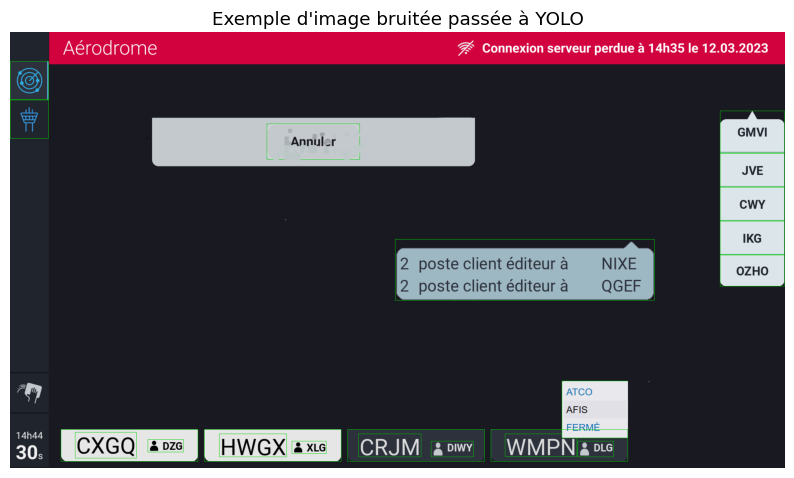

In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# --- AFFICHAGE D'UNE IMAGE BRUITÉE ---
example_image = np.array(final_images[0]) / 255.0
example_image = Image.fromarray((example_image * 255).astype(np.uint8))
example_image.save("/home/jmerhrioui/soprasteria/semaine_2/test/image_bruitee_exemple.png")

plt.figure(figsize=(10, 6))
plt.imshow(example_image)
plt.axis('off')
plt.title("Exemple d'image bruitée passée à YOLO")
plt.show()

In [21]:
# --- ÉVALUATION PAR YOLO ---
print(" Inférence YOLO...")
model_instance = model_jacques(name="bouton")

accs_all = model_instance.test_in_batches(final_images, batch_size=n_perturb)

print(f" {len(accs_all)} scores calculés")
print("Accs:", accs_all)

YOLOv5 🚀 v7.0-443-gbe00b6b6 Python-3.12.3 torch-2.8.0+cu128 CPU



 Inférence YOLO...


Fusing layers... 
Model summary: 416 layers, 140509144 parameters, 0 gradients, 209.1 GFLOPs
Adding AutoShape... 
/home/jmerhrioui/soprasteria/yolov5/models/common.py:906: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


 20 scores calculés
Accs: [0.9121689200401306, 0.4873899221420288, 0.3594546616077423, 0.8907632231712341, 0.31307461857795715, 0.83896404504776, 0.6728275418281555, 0.8691562414169312, 0.9067567586898804, 0.8300159573554993, 0.9085698127746582, 0.5658745765686035, 0.8941532969474792, 0.814841091632843, 0.4829508662223816, 0.6045215725898743, 0.8894600868225098, 0.6568520665168762, 0.9175406694412231, 0.7526252269744873]


## Faire une régression entre l'image bruitée et l'acc du model 

In [22]:
# entrée 1 : liste des accuracies des images bruitées : accs_all
# entrée 2 : liste des matrice binaire des superpixels : Z_fused 

print(f" {len(Z_all[0])} : nombre de patch dans la première image bruitée ")
print(f"{len(Z_all)} : nombre d'images bruitées.")
print(f"nbre d'acc : {len(accs_all)}")

Z_fused = []
for Z_i in Z_all:  # une liste par image bruitée
    z_concat = []
    for p, Z_patch in zip(numero, Z_i):
        seg = np.asarray(segs[p]).squeeze().astype(np.int32)
        n_sp = len(np.unique(seg))
        # Tronquer ou ajuster Z_patch au bon nombre de superpixels
        Z_patch = Z_patch[:n_sp]
        z_concat.append(Z_patch.flatten())
    Z_fused.append(np.hstack(z_concat))

print (f"Z_fused shape : {len(Z_fused)}")
print (f"Z_fused[0] shape : {Z_fused[0].shape}") # 14 *50 = 700




 14 : nombre de patch dans la première image bruitée 
20 : nombre d'images bruitées.
nbre d'acc : 20
Z_fused shape : 20
Z_fused[0] shape : (132,)


In [23]:
import sys, importlib
sys.modules.pop('lime.regression', None)  
importlib.invalidate_caches()       

from lime.regression import regression
print(" Classe importée :", regression)

reg = regression(batch_size=sp_batch_size, n_segments=n_segments, compactness=compactness, alpha=1e-5)


 Classe importée : <class 'lime.regression.regression'>


In [24]:
w = reg.regression_jacques(accs_all, Z_fused)
print("Shape w:", w.shape)  # (10, 700)
# Moyenne des poids sur toutes les régressions bruitées


[INFO] Régression LIME : 20 images, 132 superpixels
Shape w: (132,)


## On veut afficher les sp qui ont le plus d'influence

In [25]:
import numpy as np

top_percent = 1.5
print(f"Taille de w : {w.shape}, Min : {np.min(w):.4f}, Max : {np.max(w):.4f}")

w_abs = np.abs(w)
w_norm = w_abs / np.max(w_abs)
threshold = np.percentile(w_norm, 100 - top_percent)
important_idx = np.where(w_norm >= threshold)[0]

print(f"Indices top {top_percent}% :", important_idx.tolist())
print(f"Valeurs correspondantes :", w[important_idx])


Taille de w : (132,), Min : -0.4671, Max : 1.0000
Indices top 1.5% : [20, 100]
Valeurs correspondantes : [    0.58294           1]


In [26]:
patch_size = 40

# Calcul dynamique du nombre de superpixels réels par patch
n_sp_per_patch = []
mapping = []  # (patch_id, superpixel_local)

for p in numero:
    seg = np.asarray(segs[p]).squeeze().astype(np.int32)
    labels = np.unique(seg)
    n = len(labels)
    n_sp_per_patch.append(n)
    mapping.extend([(p, i) for i in range(n)])

# Vérification cohérence avec w
if len(w) != len(mapping):
    raise ValueError(f"Incohérence : len(w)={len(w)} ≠ len(mapping)={len(mapping)}. Vérifie Z_fused.")

# Affiche les superpixels les plus importants
for idx in important_idx:
    pid, local_sp = mapping[idx]
    print(f"Superpixel {idx:3d} → Patch global {pid} (local {local_sp})")


Superpixel  20 → Patch global 306 (local 7)
Superpixel 100 → Patch global 355 (local 2)


Nombre total de superpixels (len(w) attendu) : 132

Superpixels affichés :
01 → patch 355, superpixel local 2, poids = 1.0000
02 → patch 306, superpixel local 7, poids = 0.5829
03 → patch 357, superpixel local 4, poids = 0.5767
04 → patch 305, superpixel local 9, poids = 0.4384
05 → patch 355, superpixel local 9, poids = 0.4283
06 → patch 306, superpixel local 3, poids = 0.3691
07 → patch 310, superpixel local 0, poids = 0.3590
08 → patch 305, superpixel local 7, poids = 0.3548
09 → patch 309, superpixel local 3, poids = 0.2625
10 → patch 308, superpixel local 9, poids = 0.2435


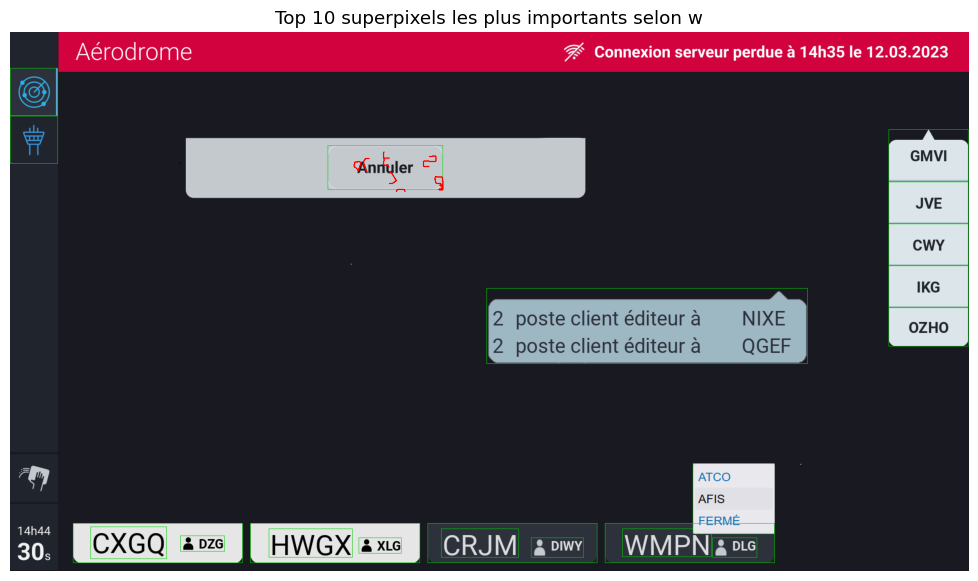

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import find_boundaries
from PIL import Image

# --- paramètres ---
patch_size = 40
img_path = "/home/jmerhrioui/soprasteria/semaine_2/data/dataset_y/images/validation/validation_image_4.png"
top_k = 10

# --- image complète ---
image = np.array(Image.open(img_path).convert("RGB"))
H, W = image.shape[:2]

# Troncature propre pour coller au maillage de patch_size
H_trunc = (H // patch_size) * patch_size
W_trunc = (W // patch_size) * patch_size
if (H_trunc != H) or (W_trunc != W):
    image = image[:H_trunc, :W_trunc]
    H, W = H_trunc, W_trunc

cols = W // patch_size

# --- NE PAS recalculer 'mapping' ici ---
# On réutilise le 'mapping' construit dans le bloc précédent (index global -> (patch_id, sp_local))
if 'mapping' not in globals():
    raise RuntimeError("Le 'mapping' n'existe pas. Exécute d'abord le bloc qui construit 'mapping'.")

print(f"Nombre total de superpixels (len(w) attendu) : {len(mapping)}")
if len(w) != len(mapping):
    raise ValueError(f"len(w)={len(w)} != len(mapping)={len(mapping)}. Harmonise Z_fused/mapping.")

# --- Sélection des top superpixels ---
indices_top = np.argsort(w)[::-1][:top_k]
top_map = [mapping[i] for i in indices_top]

print("\nSuperpixels affichés :")
for rank, (pid, sid) in enumerate(top_map, 1):
    print(f"{rank:02d} → patch {pid}, superpixel local {sid}, poids = {w[indices_top[rank-1]]:.4f}")

# --- Masque global ---
full_boundary = np.zeros((H, W), dtype=bool)

# --- Affichage des top superpixels ---
for (pid, sid), idx in zip(top_map, indices_top):
    seg = np.asarray(segs[pid]).squeeze().astype(np.int32)

    # Sécurise la taille (40x40) pour le placement dans le maillage
    if seg.shape != (patch_size, patch_size):
        seg = np.array(Image.fromarray(seg).resize((patch_size, patch_size), Image.NEAREST)).astype(np.int32)

    labels = np.unique(seg)
    if sid >= len(labels):
        print(f" Patch {pid} n’a que {len(labels)} SPs (sid={sid}) → ignoré.")
        continue

    true_label = labels[sid]
    mask = (seg == true_label)
    b = find_boundaries(mask, mode='outer')

    r, c = divmod(pid, cols)
    y0, x0 = r * patch_size, c * patch_size
    full_boundary[y0:y0+patch_size, x0:x0+patch_size] |= b

# --- Affichage final ---
plt.figure(figsize=(14, 7))
plt.imshow(image)
plt.contour(full_boundary, colors='red', linewidths=0.5)
plt.axis('off')
plt.title(f"Top {top_k} superpixels les plus importants selon w")
plt.show()
